<a href="https://colab.research.google.com/github/MaryamThk/CKD-Predictor/blob/main/Untitled8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install seaborn scikit-learn matplotlib pandas numpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# تنظیمات ظاهری برای نمودارها
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(font_scale=1.2)

# برای نمایش همه ستون‌ها و جلوگیری از خلاصه‌شدن
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ckd_cleaned_data.csv to ckd_cleaned_data.csv


In [ ]:
df_cleaned = pd.read_csv('ckd_cleaned_data.csv')

# نمایش چند سطر اول برای اطمینان
df_cleaned.head()

,id,age,bp,sg,al,su,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,pe,ane,class,rbc_normal,pc_normal,appet_poor
0,1,0.517241,0.230769,1.020,1,0,0,0,0.331169,0.355304,0.190476,0.505708,0.605522,0.815385,0.743590,0.425532,0.628571,1,1,0,0,0,1,True,True,False
1,2,0.045977,0.000000,1.020,4,0,0,0,0.331169,0.169928,0.095238,0.505708,0.605522,0.500000,0.589744,0.234043,0.514286,0,0,0,0,0,1,True,True,False
2,3,0.678161,0.230769,1.010,2,3,0,0,0.331169,0.530381,0.333333,0.505708,0.605522,0.369231,0.410256,0.393617,0.514286,0,1,0,0,1,1,True,True,True
3,4,0.517241,0.153846,1.005,4,0,1,0,0.305195,0.561277,0.809524,0.505708,0.593750,0.492308,0.435897,0.308511,0.257143,1,0,0,1,1,1,True,False,True
4,5,0.551724,0.230769,1.010,2,0,0,0,0.233766,0.252317,0.238095,0.505708,0.605522,0.523077,0.512821,0.372340,0.457143,0,0,0,0,0,1,True,True,False


In [ ]:
ckd = df_cleaned[df_cleaned['class'] == 1]
notckd = df_cleaned[df_cleaned['class'] == 0]

In [ ]:
# ستون‌های عددی بدون 'class'
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.drop('class')

# تعریف یک DataFrame برای نگهداری مقایسه
summary_stats = pd.DataFrame()

# جمع‌آوری آمار برای هر ویژگی
for col in numeric_cols:
    summary_stats.loc[col, 'CKD_Mean'] = ckd[col].mean()
    summary_stats.loc[col, 'NotCKD_Mean'] = notckd[col].mean()

    summary_stats.loc[col, 'CKD_Median'] = ckd[col].median()
    summary_stats.loc[col, 'NotCKD_Median'] = notckd[col].median()

    summary_stats.loc[col, 'CKD_Std'] = ckd[col].std()
    summary_stats.loc[col, 'NotCKD_Std'] = notckd[col].std()

    summary_stats.loc[col, 'Difference_Mean'] = summary_stats.loc[col, 'CKD_Mean'] - summary_stats.loc[col, 'NotCKD_Mean']

# مرتب‌سازی براساس تفاوت میانگین
summary_stats_sorted = summary_stats.sort_values('Difference_Mean', key=abs, ascending=False)

# نمایش
summary_stats_sorted.head(10)

,CKD_Mean,NotCKD_Mean,CKD_Median,NotCKD_Median,CKD_Std,NotCKD_Std,Difference_Mean
id,123.442211,325.500000,124.000000,325.500000,72.567526,43.445368,-202.057789
al,1.663317,0.000000,2.000000,0.000000,1.393423,0.000000,1.663317
su,0.743719,0.000000,0.000000,0.000000,1.344517,0.000000,0.743719
htn,0.608040,0.000000,1.000000,0.000000,0.489419,0.000000,0.608040
dm,0.542714,0.000000,1.000000,0.000000,0.499429,0.000000,0.542714
hemo,0.476768,0.792359,0.484615,0.784615,0.163213,0.101803,-0.315591
pe,0.306533,0.000000,0.000000,0.000000,0.462216,0.000000,0.306533
pcv,0.499162,0.799829,0.512821,0.782051,0.177099,0.106891,-0.300667
rbcc,0.404164,0.672000,0.514286,0.642857,0.170207,0.169911,-0.267836
ane,0.241206,0.000000,0.000000,0.000000,0.428894,0.000000,0.241206


/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


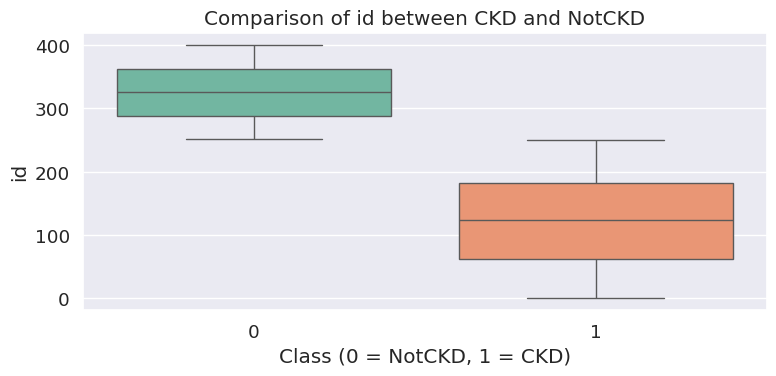

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


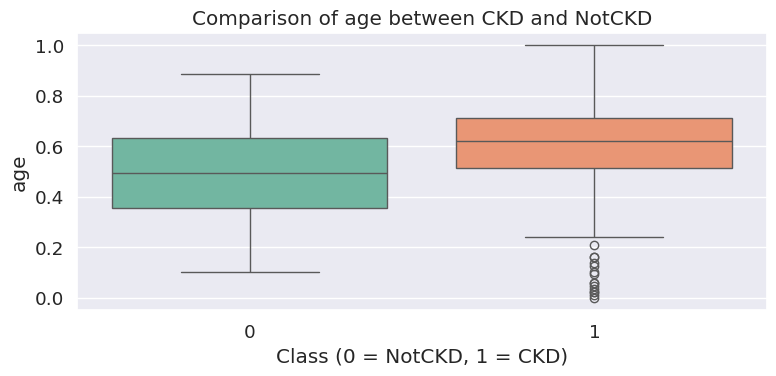

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


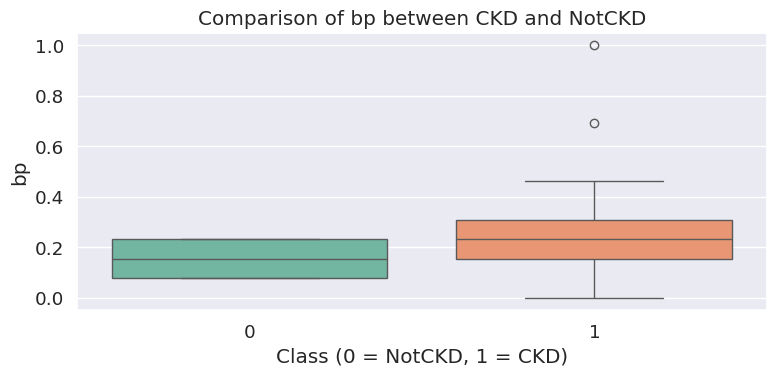

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


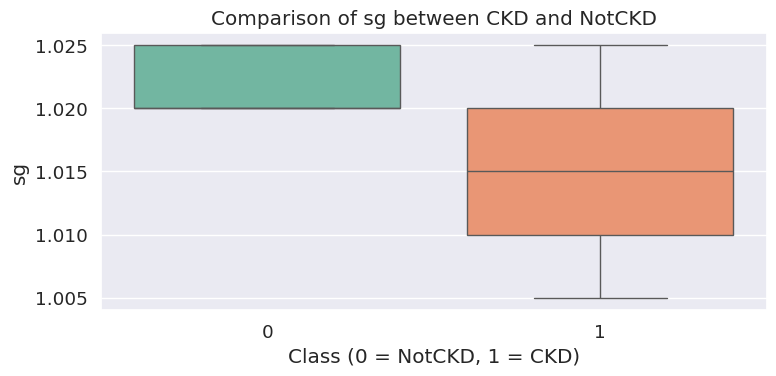

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


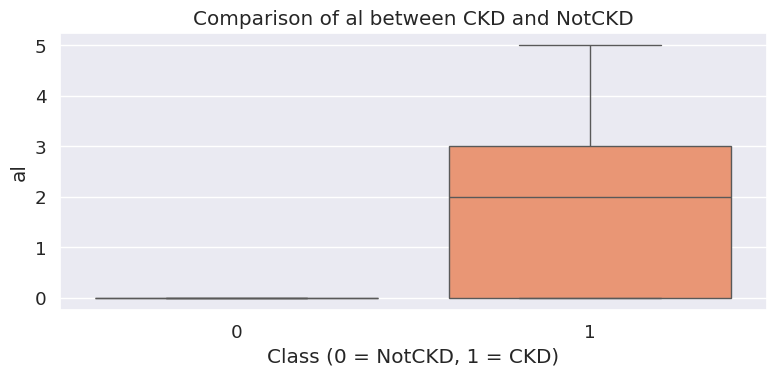

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


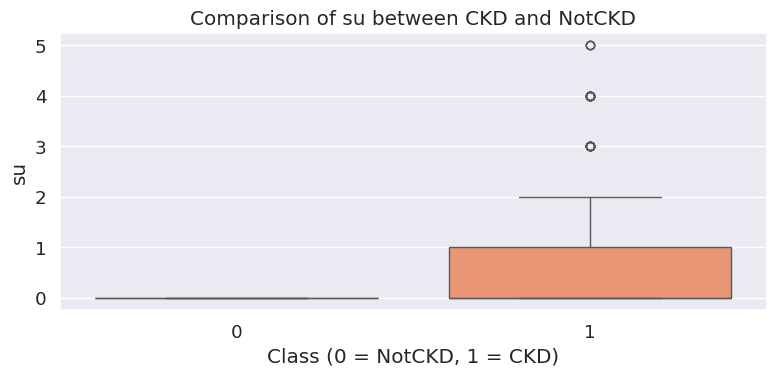

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


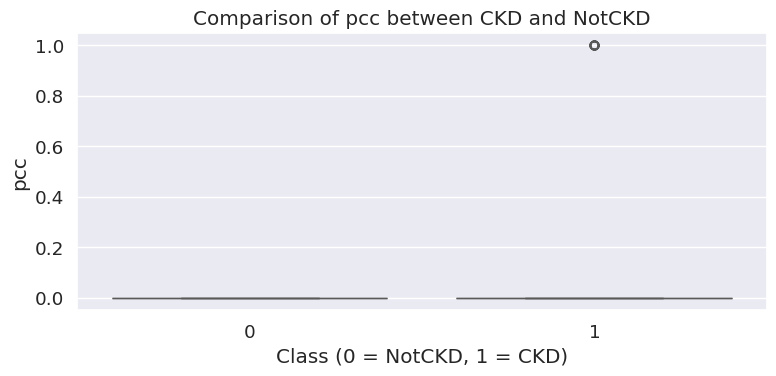

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


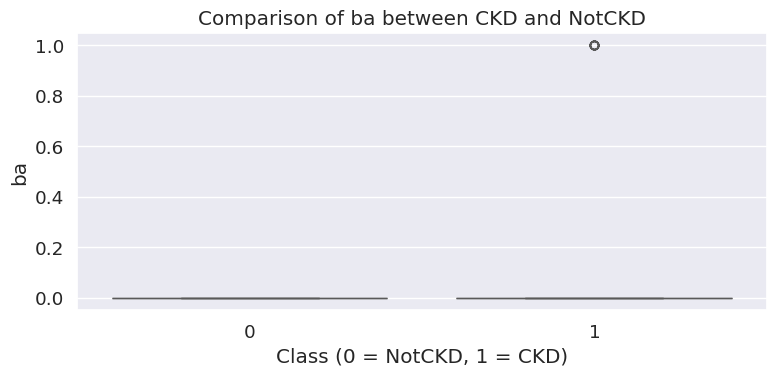

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


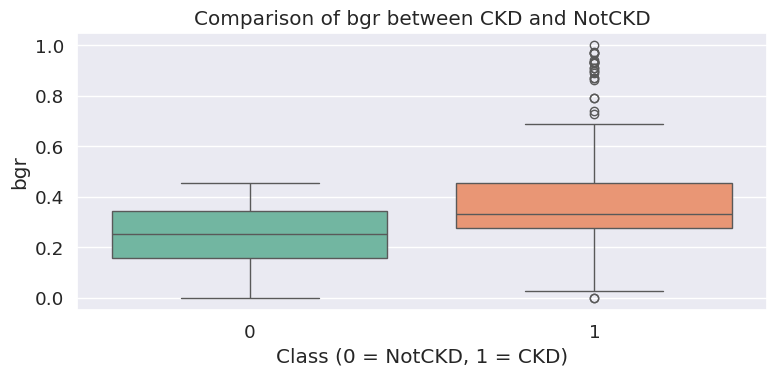

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


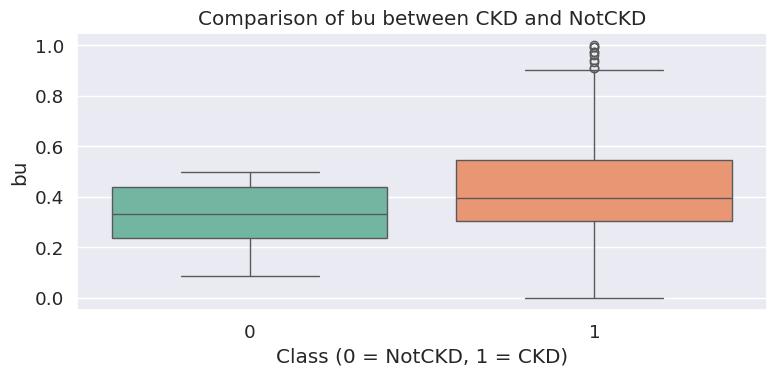

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


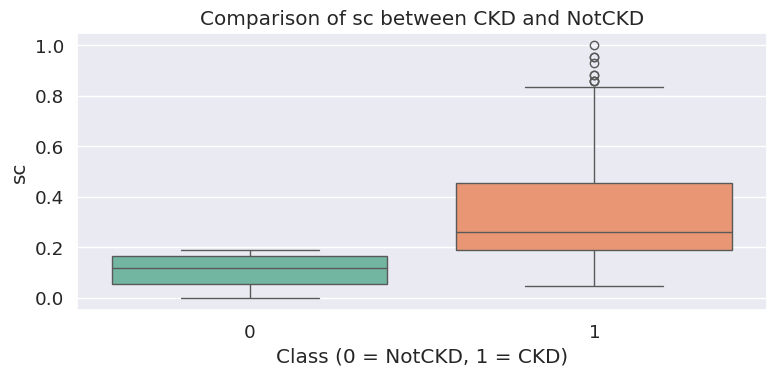

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


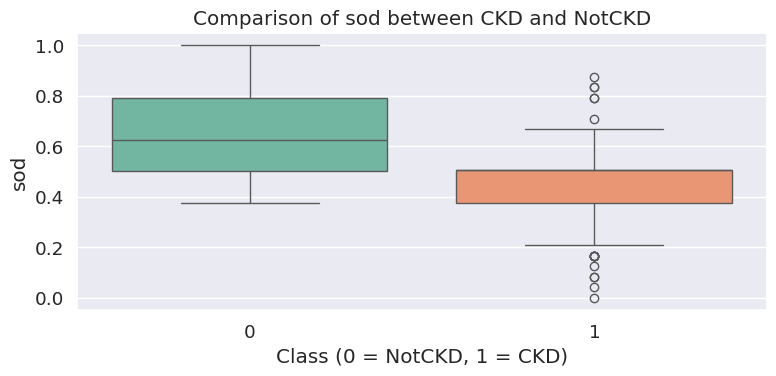

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


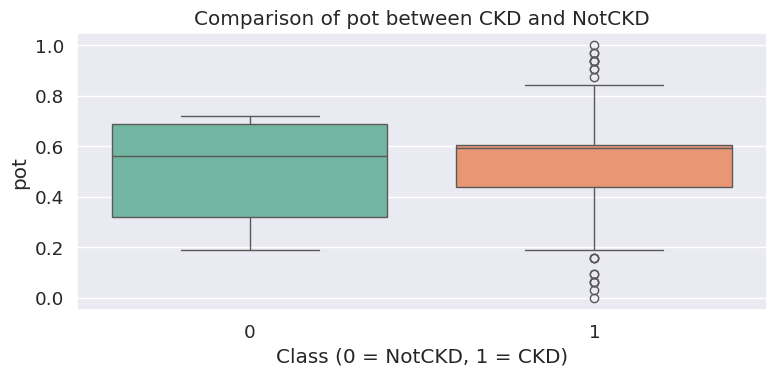

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


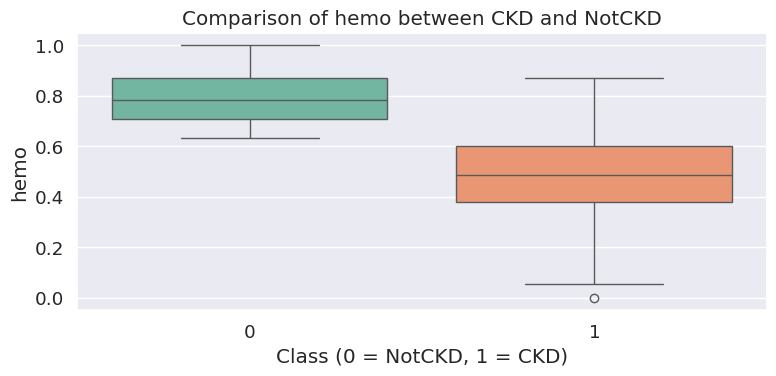

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


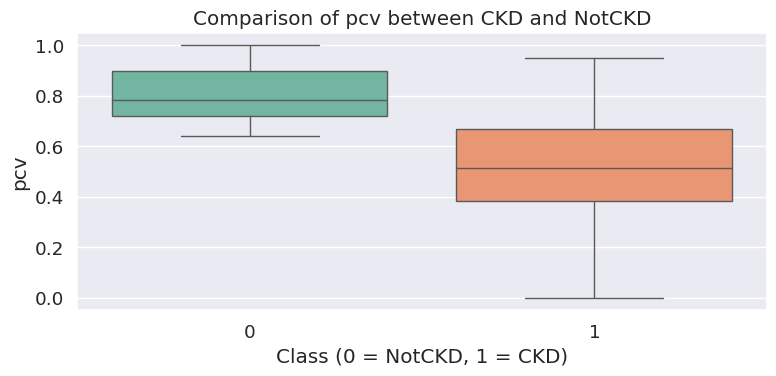

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


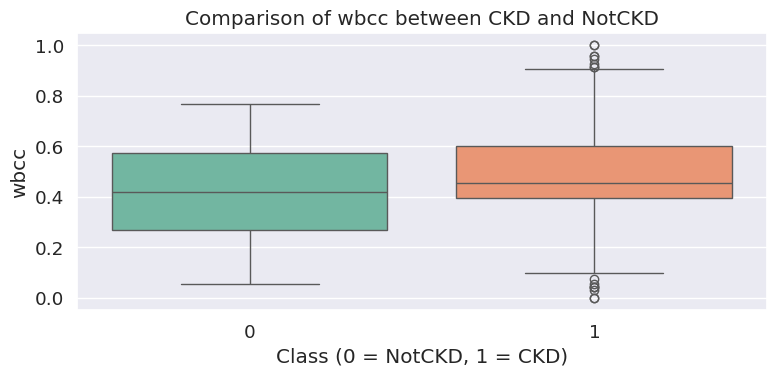

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


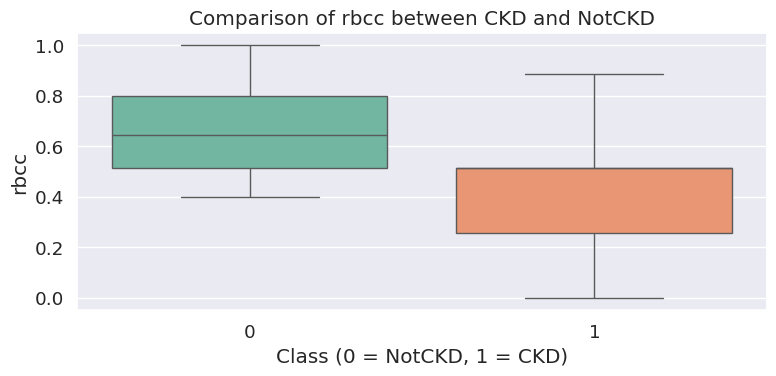

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


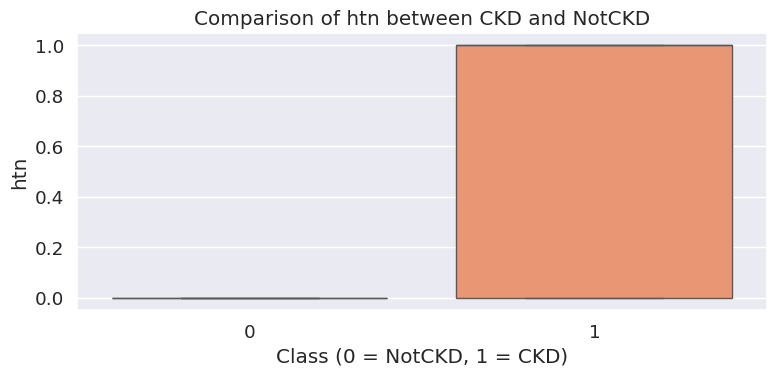

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


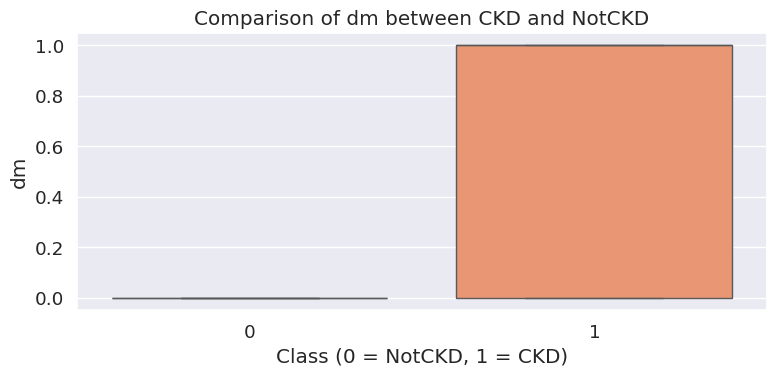

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


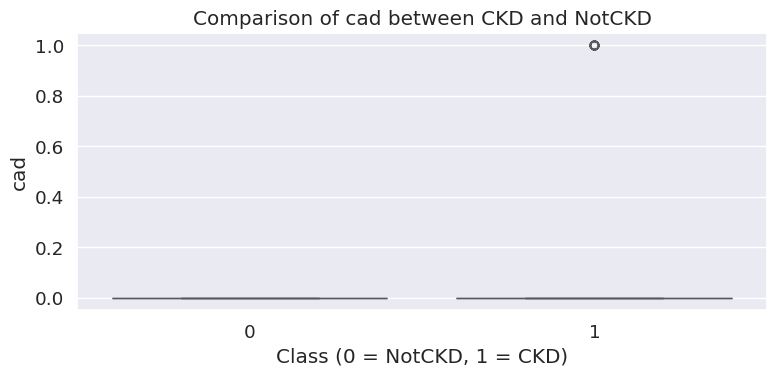

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


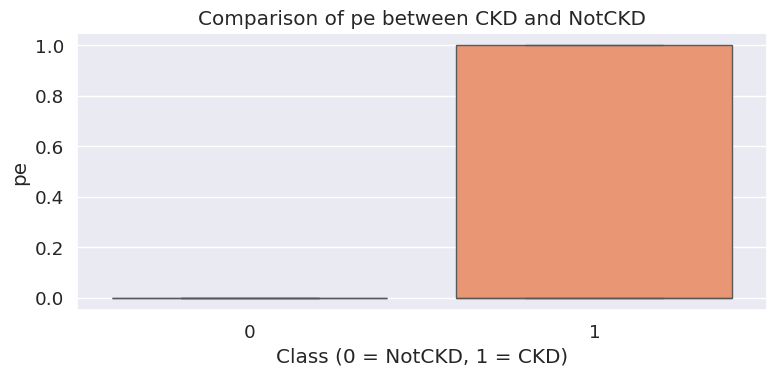

/tmp/ipython-input-2563998717.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')


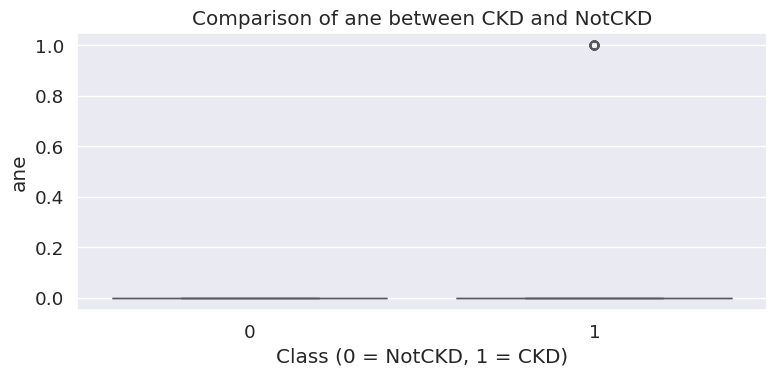

In [ ]:
# انتخاب ویژگی‌های عددی
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.drop('class')

# رسم Boxplot برای هر ویژگی عددی
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_cleaned, x='class', y=col, palette='Set2')
    plt.title(f'Comparison of {col} between CKD and NotCKD')
    plt.xlabel('Class (0 = NotCKD, 1 = CKD)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

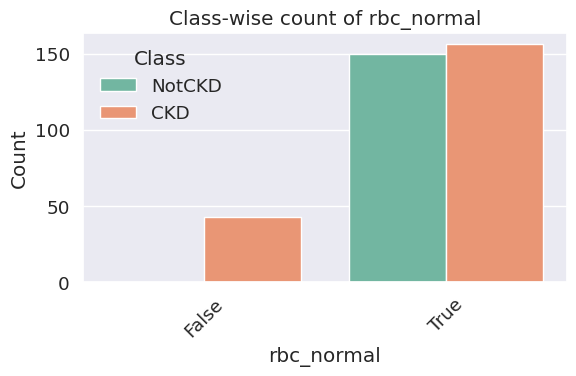

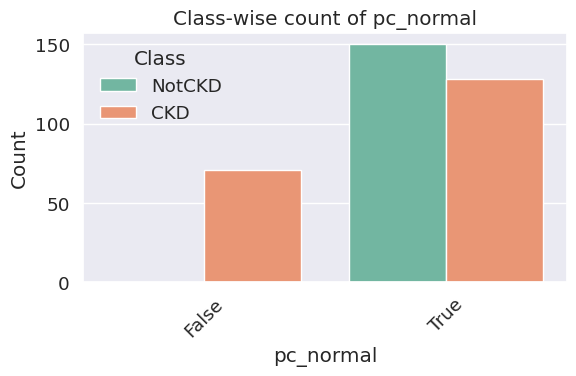

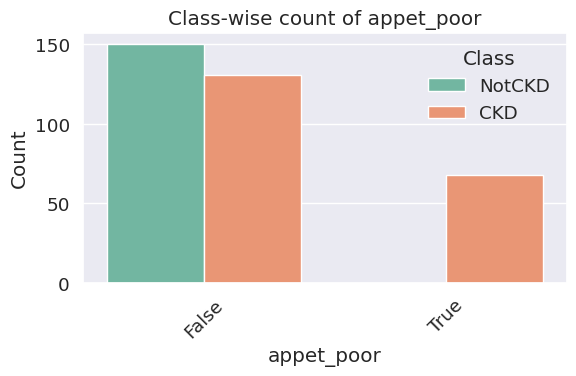

In [ ]:
# انتخاب ویژگی‌های دسته‌ای
cat_cols = df_cleaned.select_dtypes(include=['object', 'category', 'bool']).columns

# رسم countplot برای هر ویژگی دسته‌ای
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_cleaned, x=col, hue='class', palette='Set2')
    plt.title(f'Class-wise count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Class', labels=['NotCKD', 'CKD'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import ttest_ind, chi2_contingency

# فرض: df_cleaned دیتای نهایی تمیز شده و 'class' با مقادیر 1 (ckd) و 0 (notckd)

# جدا کردن دو گروه
ckd_group = df_cleaned[df_cleaned['class'] == 1]
notckd_group = df_cleaned[df_cleaned['class'] == 0]

# ---------- T-Test برای ویژگی‌های عددی ----------
numeric_features = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.drop('class')
t_test_results = []

for col in numeric_features:
    stat, p_val = ttest_ind(ckd_group[col], notckd_group[col], nan_policy='omit')
    t_test_results.append({'Feature': col, 'T-Statistic': stat, 'P-Value': p_val})

t_test_df = pd.DataFrame(t_test_results).sort_values('P-Value')
print("🎯 T-Test Results:")
display(t_test_df)

# ---------- Chi-Square برای ویژگی‌های دسته‌ای ----------
categorical_features = df_cleaned.select_dtypes(include=['object', 'category', 'bool']).columns.drop('class', errors='ignore')
chi2_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['class'])
    chi2, p_val, _, _ = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2, 'P-Value': p_val})

chi2_df = pd.DataFrame(chi2_results).sort_values('P-Value')
print("📊 Chi-Square Results:")
display(chi2_df)

🎯 T-Test Results:


,Feature,T-Statistic,P-Value
0,id,-30.253095,2.507561e-99
13,hemo,-20.820898,4.760823e-63
3,sg,-18.613375,4.084177e-54
14,pcv,-18.414170,2.625391e-53
17,htn,15.210484,2.160188e-40
4,al,14.614487,4.978588e-38
16,rbcc,-14.563844,7.886980e-38
18,dm,13.304202,6.421863e-33
10,sc,12.181618,1.158539e-28
11,sod,-10.576651,7.566910e-23


📊 Chi-Square Results:


,Feature,Chi2-Statistic,P-Value
1,pc_normal,65.002112,7.481783e-16
2,appet_poor,61.500400,4.426532e-15
0,rbc_normal,34.993540,3.308010e-09


In [ ]:
# انتخاب ویژگی‌های مهم برای خوشه‌بندی
selected_features = ['hemo', 'sg', 'al', 'sc', 'sod', 'bu', 'bgr', 'pcv', 'rbcc', 'wbcc', 'pc_normal', 'appet_poor', 'rbc_normal']

# تبدیل categorical ها به عددی (با get_dummies)
df_cluster = pd.get_dummies(df_cleaned[selected_features], drop_first=True)

# نرمال‌سازی ویژگی‌ها (برای اینکه مقیاس همه برابر بشه)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

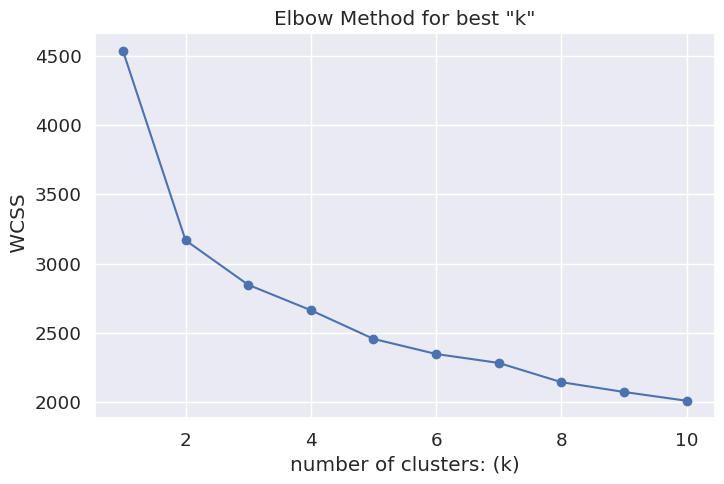

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-cluster sum of squares

# امتحان k از 1 تا 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# رسم نمودار Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('number of clusters: (k)')
plt.ylabel(' WCSS')
plt.title('Elbow Method for best "k"')
plt.grid(True)
plt.show()

In [ ]:
# اجرای KMeans با k=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# اضافه کردن برچسب خوشه‌ها به دیتافریم اصلی
df_cleaned['cluster'] = clusters

In [ ]:
# محاسبه میانگین ویژگی‌ها در هر خوشه
df_cleaned.groupby('cluster')[selected_features].mean()

,hemo,sg,al,sc,sod,bu,bgr,pcv,rbcc,wbcc,pc_normal,appet_poor,rbc_normal
cluster,,,,,,,,,,,,,
0,0.438894,1.014063,1.893750,0.378199,0.439130,0.493859,0.413068,0.460256,0.371071,0.482680,0.562500,0.387500,0.750000
1,0.759300,1.020952,0.148148,0.129504,0.624061,0.310159,0.261424,0.770723,0.644747,0.427305,0.994709,0.031746,0.984127


In [ ]:
# انتخاب 13 ویژگی مهم برای خوشه‌بندی
selected_features = [
    'hemo', 'sg', 'pcv', 'sc', 'sod', 'bgr', 'bu', 'al', 'rbcc',
    'dm', 'htn', 'appet_poor', 'pc_normal'
]

# انتخاب فقط این ویژگی‌ها برای خوشه‌بندی
X_selected = df_cleaned[selected_features].copy()

# اطمینان از اینکه داده‌ها عددی هستند (ویژگی‌های دسته‌ای را به عددی تبدیل می‌کنیم)
X_encoded = pd.get_dummies(X_selected, drop_first=True)

# نرمال‌سازی ویژگی‌ها
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

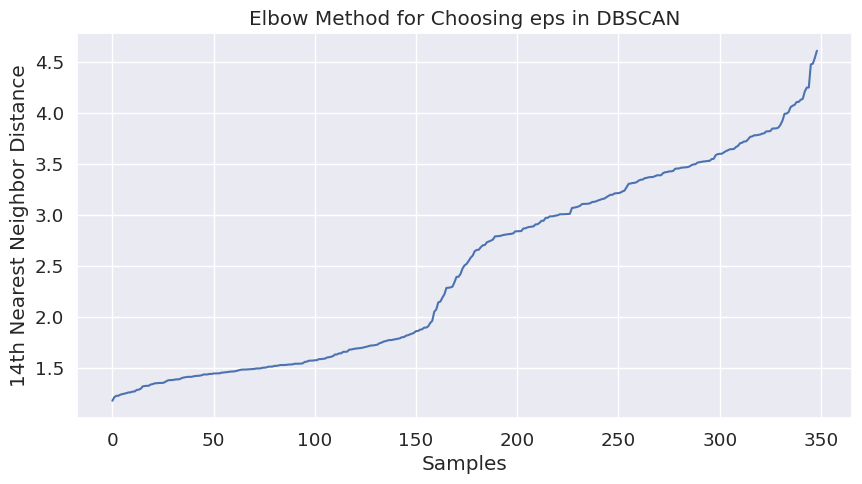

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# استفاده از NearestNeighbors برای کمک به تعیین eps
neighbors = NearestNeighbors(n_neighbors=14)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# رسم فاصله‌ها برای انتخاب مناسب eps
distances = np.sort(distances[:, 9])  # فاصله 14همین همسایه
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title("Elbow Method for Choosing eps in DBSCAN")
plt.xlabel("Samples")
plt.ylabel("14th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

تعداد نمونه در هر خوشه:
DBSCAN_Cluster
 0    211
-1    104
 1     17
 3      9
 2      8
Name: count, dtype: int64


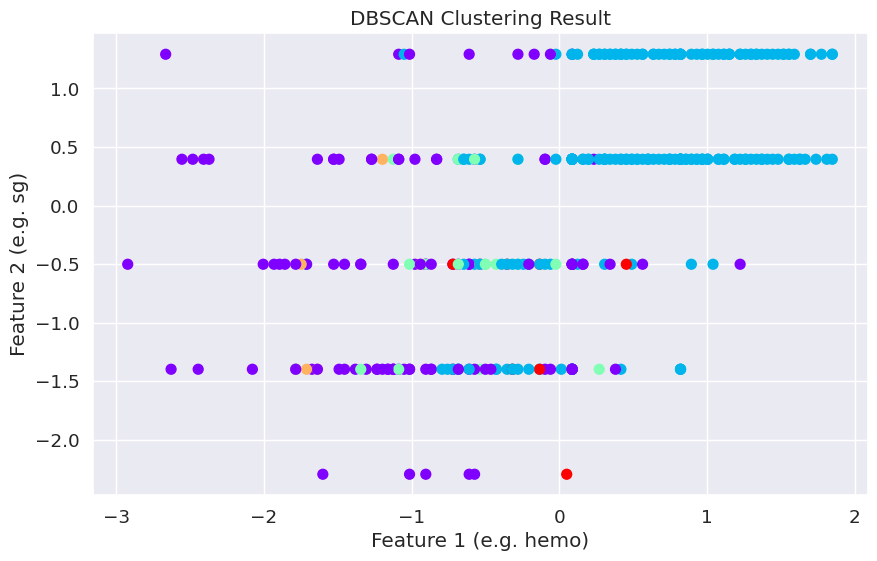

In [ ]:
# اجرای DBSCAN با پارامترهای تنظیم‌شده
dbscan = DBSCAN(eps=2.7, min_samples=9)
dbscan_labels = dbscan.fit_predict(X_scaled)

# اضافه کردن لیبل خوشه‌ها به دیتافریم
df_cleaned['DBSCAN_Cluster'] = dbscan_labels

# نمایش تعداد نمونه در هر خوشه
print("تعداد نمونه در هر خوشه:")
print(df_cleaned['DBSCAN_Cluster'].value_counts())

# رسم دو ویژگی مهم در یک نمودار دو بعدی برای دیدن خوشه‌ها
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels, cmap='rainbow', s=50)
plt.xlabel('Feature 1 (e.g. hemo)')
plt.ylabel('Feature 2 (e.g. sg)')
plt.title('DBSCAN Clustering Result')
plt.grid(True)
plt.show()

In [ ]:
# تست مقادیر مختلف
for eps in [0.5, 1.0, 1.2, 1.5, 2.0, 2.5, 2.7, 3, 3.5]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps} → Clusters: {n_clusters} | Outliers: {n_noise}"
    )

eps=0.5 → Clusters: 0 | Outliers: 349
eps=1.0 → Clusters: 0 | Outliers: 349
eps=1.2 → Clusters: 1 | Outliers: 339
eps=1.5 → Clusters: 1 | Outliers: 211
eps=2.0 → Clusters: 1 | Outliers: 181
eps=2.5 → Clusters: 3 | Outliers: 145
eps=2.7 → Clusters: 3 | Outliers: 116
eps=3 → Clusters: 2 | Outliers: 57
eps=3.5 → Clusters: 1 | Outliers: 12


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, method_name):
    print(f"📈 Evaluation for {method_name}")
    print("Silhouette Score:", silhouette_score(X, labels))
    print("Calinski-Harabasz Index:", calinski_harabasz_score(X, labels))
    print("Davies-Bouldin Index:", davies_bouldin_score(X, labels))
    print("-" * 40)

# فرض: X_scaled همان داده‌های نرمال‌سازی‌شده روی 13 ویژگی مهم است
evaluate_clustering(X_scaled, kmeans.labels_, "KMeans")
evaluate_clustering(X_scaled, dbscan.labels_, "DBSCAN")

📈 Evaluation for KMeans
Silhouette Score: 0.3231745335898676
Calinski-Harabasz Index: 184.81192732270446
Davies-Bouldin Index: 1.3130404828293332
----------------------------------------
📈 Evaluation for DBSCAN
Silhouette Score: 0.12922495454439673
Calinski-Harabasz Index: 46.910329684300166
Davies-Bouldin Index: 2.0498628521382694
----------------------------------------


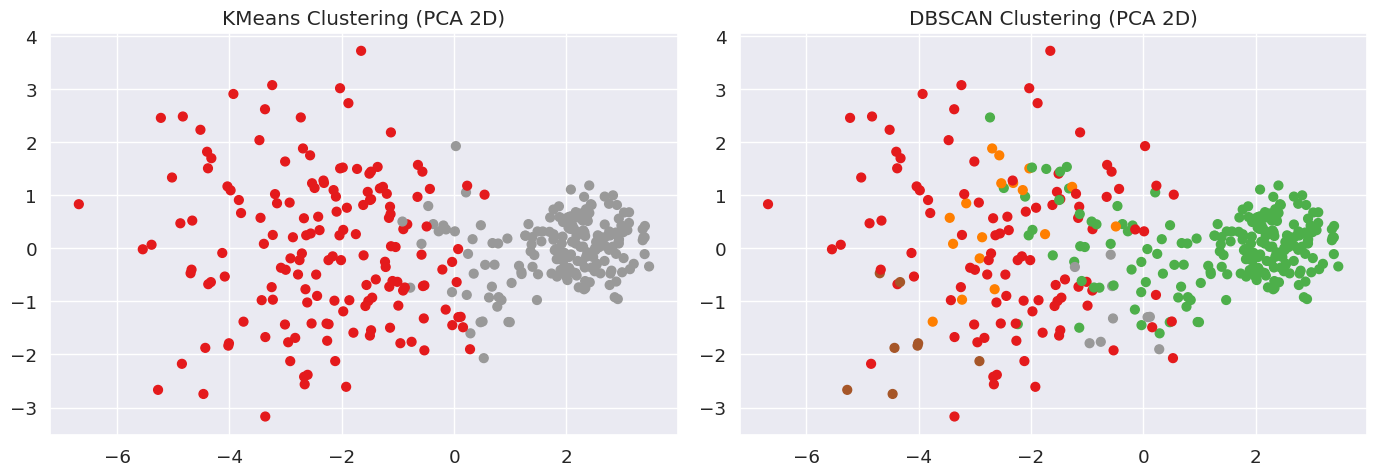

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# KMeans
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='Set1', s=40)
axs[0].set_title("KMeans Clustering (PCA 2D)")

# DBSCAN
axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan.labels_, cmap='Set1', s=40)
axs[1].set_title("DBSCAN Clustering (PCA 2D)")

plt.tight_layout()
plt.show()

/tmp/ipython-input-3624123238.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(set(kmeans.labels_)))
/tmp/ipython-input-3624123238.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3624123238.py:31: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

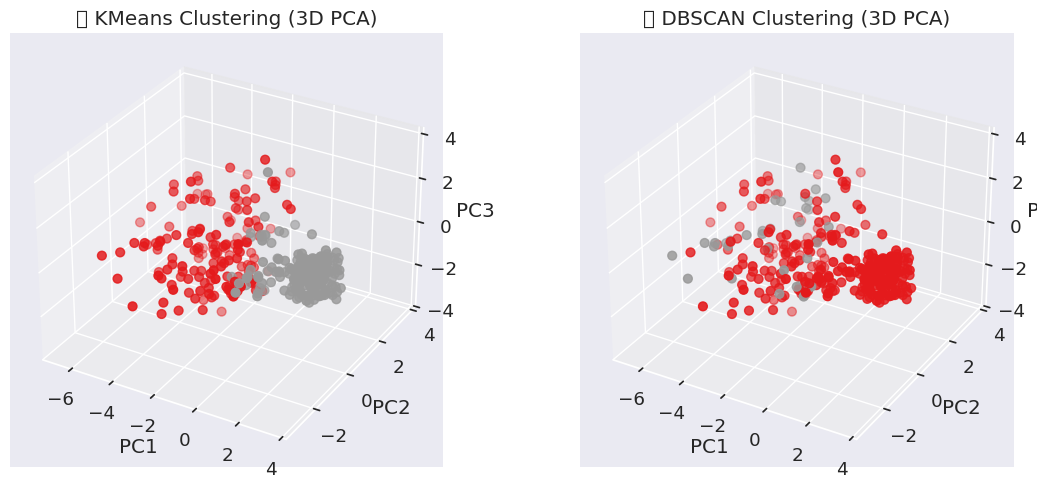

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# کاهش ابعاد به 3 مؤلفه اصلی
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# تعریف رنگ‌بندی
cmap = plt.cm.get_cmap('Set1', len(set(kmeans.labels_)))

# رسم نمودار KMeans
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection='3d')
sc = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                c=kmeans.labels_, cmap=cmap, s=40)
ax.set_title("🎯 KMeans Clustering (3D PCA)")
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# رسم نمودار DBSCAN
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                  c=dbscan.labels_, cmap=cmap, s=40)
ax2.set_title("🔍 DBSCAN Clustering (3D PCA)")
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned.info()
df_cleaned['class'].value_counts()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              349 non-null    int64  
 1   age             349 non-null    float64
 2   bp              349 non-null    float64
 3   sg              349 non-null    float64
 4   al              349 non-null    int64  
 5   su              349 non-null    int64  
 6   pcc             349 non-null    int64  
 7   ba              349 non-null    int64  
 8   bgr             349 non-null    float64
 9   bu              349 non-null    float64
 10  sc              349 non-null    float64
 11  sod             349 non-null    float64
 12  pot             349 non-null    float64
 13  hemo            349 non-null    float64
 14  pcv             349 non-null    float64
 15  wbcc            349 non-null    float64
 16  rbcc            349 non-null    float64
 17  htn             349 non-null    int

,id,age,bp,sg,al,su,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,pe,ane,class,rbc_normal,pc_normal,appet_poor,cluster,DBSCAN_Cluster
0,1,0.517241,0.230769,1.020,1,0,0,0,0.331169,0.355304,0.190476,0.505708,0.605522,0.815385,0.743590,0.425532,0.628571,1,1,0,0,0,1,True,True,False,1,0
1,2,0.045977,0.000000,1.020,4,0,0,0,0.331169,0.169928,0.095238,0.505708,0.605522,0.500000,0.589744,0.234043,0.514286,0,0,0,0,0,1,True,True,False,1,0
2,3,0.678161,0.230769,1.010,2,3,0,0,0.331169,0.530381,0.333333,0.505708,0.605522,0.369231,0.410256,0.393617,0.514286,0,1,0,0,1,1,True,True,True,0,-1
3,4,0.517241,0.153846,1.005,4,0,1,0,0.305195,0.561277,0.809524,0.505708,0.593750,0.492308,0.435897,0.308511,0.257143,1,0,0,1,1,1,True,False,True,0,-1
4,5,0.551724,0.230769,1.010,2,0,0,0,0.233766,0.252317,0.238095,0.505708,0.605522,0.523077,0.512821,0.372340,0.457143,0,0,0,0,0,1,True,True,False,0,0


In [ ]:
X = df_cleaned.drop(columns=['class'])  # ویژگی‌ها
y = df_cleaned['class']                 # برچسب هدف (label)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# مدل‌ها
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
svm_model = SVC(probability=True, random_state=42)

# آموزش
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)          # Random Forest نیاز به scale نداره
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import numpy as np

# مدل‌ها با pipeline برای استانداردسازی
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# مدل‌ها همراه با استانداردسازی (برای SVM و LR لازمه)
lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
rf_pipeline = RandomForestClassifier(random_state=42)  # RF نیاز به scaling نداره
svm_pipeline = make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "SVM": svm_pipeline
}

# اجرای 5-fold cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"✅ {name}:")
    print(f"  دقت میانگین: {scores.mean():.4f}")
    print(f"  انحراف معیار: {scores.std():.4f}")
    print("-" * 40)

✅ Logistic Regression:
  دقت میانگین: 1.0000
  انحراف معیار: 0.0000
----------------------------------------
✅ Random Forest:
  دقت میانگین: 0.9799
  انحراف معیار: 0.0250
----------------------------------------
✅ SVM:
  دقت میانگین: 0.9971
  انحراف معیار: 0.0057
----------------------------------------


In [ ]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# فرض: X و y آماده‌سازی شدن و شامل ویژگی‌ها و لیبل هستن
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True)
}

for name, model in models.items():
    print(f"🔍 Model: {name}")

    # پیش‌بینی با cross-validation
    y_pred = cross_val_predict(model, X, y, cv=skf)

    # محاسبه متریک‌ها
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"✅ Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"📈 Recall:    {rec:.4f}")
    print(f"🔁 F1-Score:  {f1:.4f}")
    print("📋 Classification Report:\n", classification_report(y, y_pred, digits=4))
    print("-" * 40)

🔍 Model: Logistic Regression
✅ Accuracy:  1.0000
🎯 Precision: 1.0000
📈 Recall:    1.0000
🔁 F1-Score:  1.0000
📋 Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       150
           1     1.0000    1.0000    1.0000       199

    accuracy                         1.0000       349
   macro avg     1.0000    1.0000    1.0000       349
weighted avg     1.0000    1.0000    1.0000       349

----------------------------------------
🔍 Model: Random Forest
✅ Accuracy:  1.0000
🎯 Precision: 1.0000
📈 Recall:    1.0000
🔁 F1-Score:  1.0000
📋 Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       150
           1     1.0000    1.0000    1.0000       199

    accuracy                         1.0000       349
   macro avg     1.0000    1.0000    1.0000       349
weighted avg     1.0000    1.0000    1.0000       349

----------------------------------------


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# شبکه پارامترها
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# اجرای GridSearchCV با 5-fold
svm_grid = GridSearchCV(SVC(), svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X, y)

# بهترین مدل و پارامترها
best_svm = svm_grid.best_estimator_
print("✅ Best Parameters:", svm_grid.best_params_)
print("🎯 Best Cross-Validation Accuracy:", svm_grid.best_score_)

# دوباره ارزیابی روی کل داده (یا تست‌ست جدا اگر داری)
y_pred = best_svm.predict(X)
print("\n📋 Final Evaluation on Data:")
print("🔍 Accuracy:", accuracy_score(y, y_pred))
print(classification_report(y, y_pred))

✅ Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
🎯 Best Cross-Validation Accuracy: 0.9075362318840579

📋 Final Evaluation on Data:
🔍 Accuracy: 0.9770773638968482
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       150
           1       1.00      0.96      0.98       199

    accuracy                           0.98       349
   macro avg       0.97      0.98      0.98       349
weighted avg       0.98      0.98      0.98       349



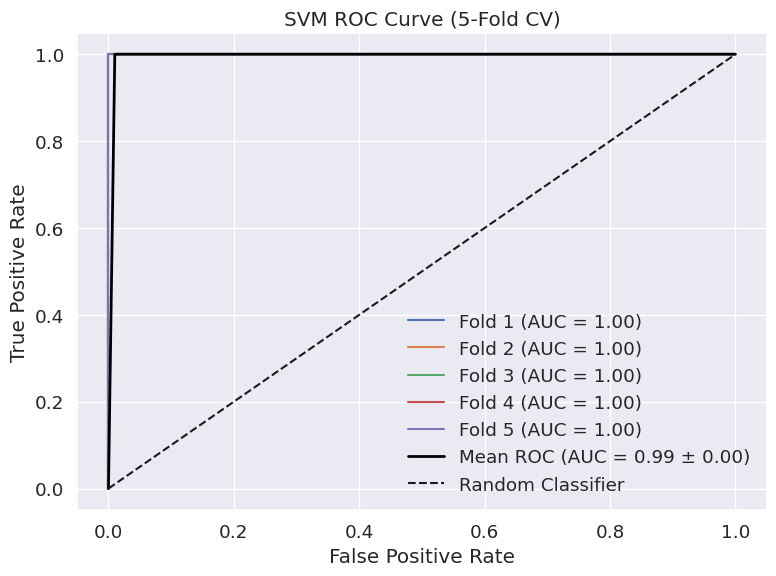

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model_name = 'SVM'

# Cross Validation
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_scores = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, lw=1.5, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')

mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='black', lw=2,
         label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'{model_name} ROC Curve (5-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

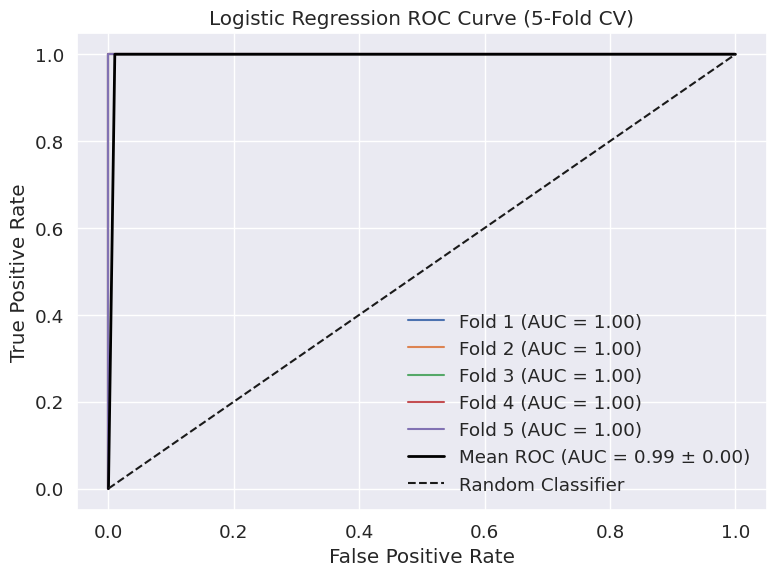

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model_name = 'Logistic Regression'

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, lw=1.5, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')

mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='black', lw=2,
         label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'{model_name} ROC Curve (5-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

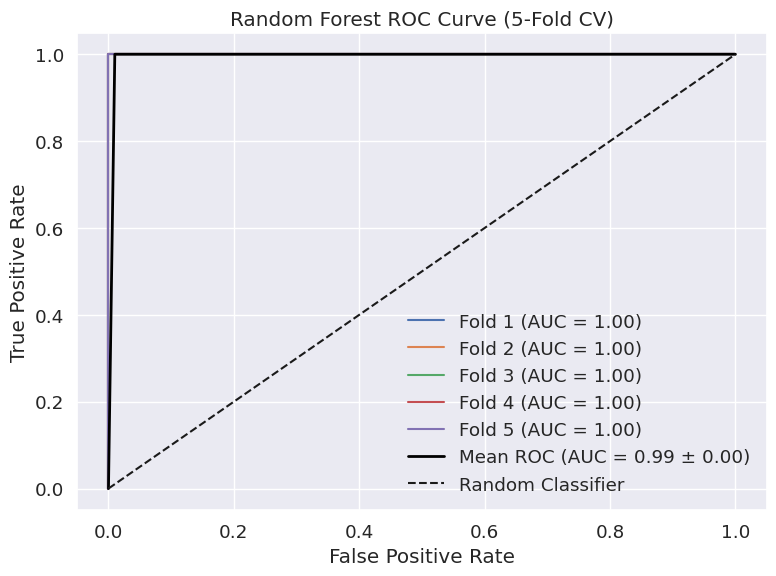

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model_name = 'Random Forest'

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8, 6))
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_scores = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, lw=1.5, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')

mean_tpr = np.mean(tprs, axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

plt.plot(mean_fpr, mean_tpr, color='black', lw=2,
         label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'{model_name} ROC Curve (5-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

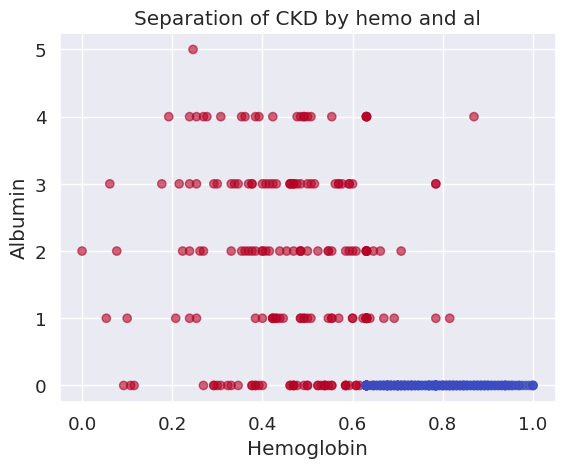

In [ ]:
plt.scatter(X['hemo'], X['al'], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel('Hemoglobin')
plt.ylabel('Albumin')
plt.title('Separation of CKD by hemo and al')
plt.show()